In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
df=pd.read_csv("/kaggle/input/cyberbullying/Multilablel Cyberbully Data.csv")
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam
9030,female,social,তরে চুদুম,1,1,0,0,0
6136,female,social,অনুমোতি ছরা টিকনা,1,0,0,0,0
5574,female,actor,মানি মানি মানি নরম জিনিষের ছোয়ায় যখন গরম আসে ন...,1,1,0,0,0
788,female,social,তাই বুঝি,1,0,0,0,0
7958,female,social,ইজত পাইলাম না,1,0,0,0,0
4148,female,actor,এই সে পরীমনি,1,0,0,0,0
10227,female,social,বিশ্ব বেতামি মেয়ে,1,0,0,0,0
1410,male,sports,ওমাগো টু লাভ,1,0,0,0,0
1791,female,social,স্ত্রী জেমন নস্টো হাসবন্দ ওহ এমন নস্টো আল্লাহ ...,1,0,1,0,0
2483,female,social,ভাই লাইক ও ভিলেন করে দিলাম,0,0,0,0,1


In [3]:
#check the rows and columns number.
print(f"number of rows:--> {df.shape[0]} and number of columns:--> {df.shape[1]}")

number of rows:--> 12546 and number of columns:--> 8


In [4]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12546 entries, 0 to 12545
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      12546 non-null  object
 1   Profession  12546 non-null  object
 2   comment     12546 non-null  object
 3   bully       12546 non-null  int64 
 4   sexual      12546 non-null  int64 
 5   religious   12546 non-null  int64 
 6   threat      12546 non-null  int64 
 7   spam        12546 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 784.3+ KB


In [5]:
#check for missing values 
def checking_m(df):
    null_v = df.isnull().sum().sort_values(ascending=False)
    null_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    null_v = pd.concat([null_v, null_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return null_v

checking_m(df)

,Missing_Number,Missing_Percent
Gender,0,0.0
Profession,0,0.0
comment,0,0.0
bully,0,0.0
sexual,0,0.0
religious,0,0.0
threat,0,0.0
spam,0,0.0


In [6]:
#check for dublicated rows
print("Numbers of duplicated rows :",df.duplicated().sum())

Numbers of duplicated rows : 1291


In [7]:
#counting text length
df['count'] = df['comment'].str.split().str.len()

# Remove the text with words less than 3
df= df.loc[df['count']>2]


In [8]:
df.shape

(10188, 9)

In [9]:
df.sample(50)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
3356,female,politics,হাসিনা কে আবার জেলে পাঠাবো ইনশাআল্লাহ,1,0,1,1,0,6
10488,female,actor,আরে বোন আ\nআর একটু দেকিয়ে দেও তুমি যে ওয়ার্ল্ড...,1,0,0,0,0,13
11665,female,actor,আজ থেকে তর সকল নাটক থেকে নিজেকে ফিরিয়ে নিলামদূ...,1,0,1,1,0,13
6977,female,social,আমি যা দেখছি সবাই কি দেখছে,1,0,0,0,0,6
10948,female,actor,এত দেখি গরু মেরে জুতা দান করার মত,1,0,0,0,0,8
7209,female,social,এত বড় ধুদ,1,1,0,0,0,3
3942,female,actor,লালের ভিতর সাদা,1,1,0,0,0,3
6657,female,dancer,তোমার গর্তে আমার একটু ঘুরে আসতে মন চায় নিবা আ...,1,1,0,0,0,10
1853,female,politics,আমি ও হবো,0,0,0,0,0,3
1101,male,social,আপনার মা তো সেই মাল,1,1,0,0,0,5


In [10]:
import re

def clean_bangla_text(text):
    # Remove English letters and digits only
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Remove unwanted punctuation (but keep । ! ? , )
    text = re.sub(r'[“”"\'’‘`^~–—…•°•→←<>/\\|_=+()*&^%$#@{}[\]<>]', ' ', text)

    # Remove newlines and tabs
    text = text.replace("\n", " ").replace("\t", " ")

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['comment'] = df['comment'].apply(clean_bangla_text)

In [11]:
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
11332,female,actor,জুতা মার সালিরে,1,0,0,1,0,3
2194,male,politics,টিকটকে কেন হাহাহা কোন নেই,0,0,0,0,0,6
11068,female,actor,জুতা মার ঔ মাগির কপালে,1,0,0,1,0,5
11897,female,actor,জুতা মারো জুতা মারা সাফা কবির কে জুতা মারো,1,0,0,1,0,9
11761,female,actor,তোকে জুতা মারি,1,0,0,1,0,3
1861,female,politics,নুপুর পুলিশ আকতার,1,0,0,0,0,3
6200,female,social,গার্মেন্টস কর্মী লাগছে বিয়ান ন,1,0,0,0,0,5
7099,female,social,পম পম পম পম পম,1,1,0,0,0,5
11740,female,actor,জুতা পিটা খাবি,1,0,0,1,0,3
948,female,social,আপু তোমার নাম কি,0,0,0,0,0,4


In [12]:
# Length of each cleaned comment (in tokens/words, split by space)
df['token_len'] = df['comment'].apply(lambda x: len(x.split()))

# Maximum token length
max_token_len = df['token_len'].max()

print("Maximum token length:", max_token_len)
df[['comment', 'token_len']].head()


Maximum token length: 178


,comment,token_len
0,এই দেশে এইসব কি হচ্ছে,5
1,মানে কি বলব,3
2,ভাই ভিডিও ফুল প্লিজ,4
3,নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...,14
4,ভিডিও কলে রেগুলার কাজ করতে পারবেন,6


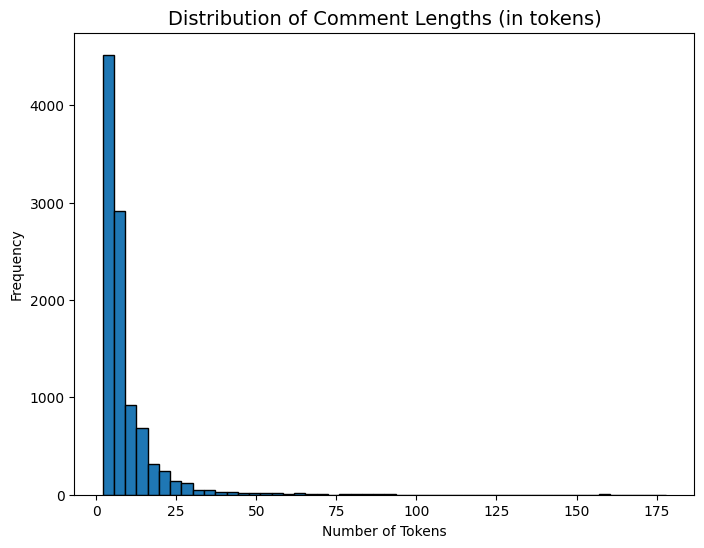

In [13]:
import matplotlib.pyplot as plt

# Distribution of token lengths (assuming you already added df['token_len'])
plt.figure(figsize=(8,6))
plt.hist(df['token_len'], bins=50, edgecolor='black')
plt.title("Distribution of Comment Lengths (in tokens)", fontsize=14)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [14]:
# Define label columns
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Prepare features and labels
texts = df['comment'].values
labels = df[label_cols].values.astype(np.float32)

labels

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 1., 0., 0.]], dtype=float32)

In [15]:
print(f"Dataset size: {len(texts)}")
print(f"Label distribution:\n{df[label_cols].sum()}")


Dataset size: 10188
Label distribution:
bully        6882
sexual       1802
religious    1445
threat       1403
spam          933
dtype: int64


In [16]:
# Train-validation-test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels.sum(axis=1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.sum(axis=1)
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 8150, Val: 1019, Test: 1019


# ================== BERT+Bi-LSTM ==========================

In [17]:
# ========================
# 2. DATASET CLASS
# ========================

class CyberbullyingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)  
        if isinstance(labels, pd.DataFrame):
            self.labels = labels.values 
        else:
            self.labels = np.array(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]  # now works fine with numpy

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float)
        }


In [18]:
# ========================
# 3. MODEL ARCHITECTURE: BERT + BiLSTM
# ========================

class BERTBiLSTM(nn.Module):
    def __init__(self, bert_model_name, num_labels, hidden_dim=256, lstm_layers=2, dropout=0.3):
        super(BERTBiLSTM, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.lstm = nn.LSTM(
            self.bert.config.hidden_size,
            hidden_dim,
            num_layers=lstm_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        
        lstm_output, (hidden, cell) = self.lstm(sequence_output)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits


In [19]:
# ========================
# 4. TRAINING FUNCTION
# ========================

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [20]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

# Configuration
BERT_MODEL = 'csebuetnlp/banglabert_large'  # Bengali BERT model
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-5

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [24]:
# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [22]:
# Initialize model
model = BERTBiLSTM(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTBiLSTM")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

2025-10-07 08:17:17.556197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759825038.006735      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759825038.110734      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.35G [00:00<?, ?B/s]


Model: BERTBiLSTM
Total parameters: 339,810,821


In [25]:
# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [24]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint.pt')
    print(f"✓ Last model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.5405 | Train Acc: 0.8074
Val Loss: 0.3661 | Val Acc: 0.8585
✓ Last model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0717 | Train Acc: 0.9822
Val Loss: 0.2115 | Val Acc: 0.9388
✓ Last model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0661 | Train Acc: 0.9840
Val Loss: 0.2117 | Val Acc: 0.9388
✓ Last model checkpoint saved! (Epoch 10)

TRAINING COMPLETED

FINAL TRAINING METRICS:
Last Train Loss: 0.0661
Last Train Accuracy: 0.9840
Last Validation Loss: 0.2117
Last Validation Accuracy: 0.9388


In [25]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS
Test Loss: 0.2002
Test Accuracy: 0.9384
Hamming Loss: 0.0616


In [26]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8680
Recall: 0.8819
F1-Score: 0.8749


In [27]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       bully       0.91      0.94      0.92       693
      sexual       0.65      0.68      0.67       155
   religious       0.89      0.92      0.90       143
      threat       0.88      0.84      0.86       164
        spam       0.90      0.83      0.87        90

   micro avg       0.87      0.88      0.87      1245
   macro avg       0.85      0.84      0.84      1245
weighted avg       0.87      0.88      0.87      1245
 samples avg       0.73      0.73      0.71      1245



In [28]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7413, Cohen's Kappa = 0.7403
    sexual: MCC = 0.6080, Cohen's Kappa = 0.6078
 religious: MCC = 0.8875, Cohen's Kappa = 0.8874
    threat: MCC = 0.8339, Cohen's Kappa = 0.8336
      spam: MCC = 0.8556, Cohen's Kappa = 0.8547

Average Scores:
MCC: 0.7853
Cohen's Kappa: 0.7848


In [29]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS
bully: 0.9151
sexual: 0.8824
religious: 0.9774
threat: 0.9558
spam: 0.9604

Micro AUC: 0.9621
Macro AUC: 0.9382


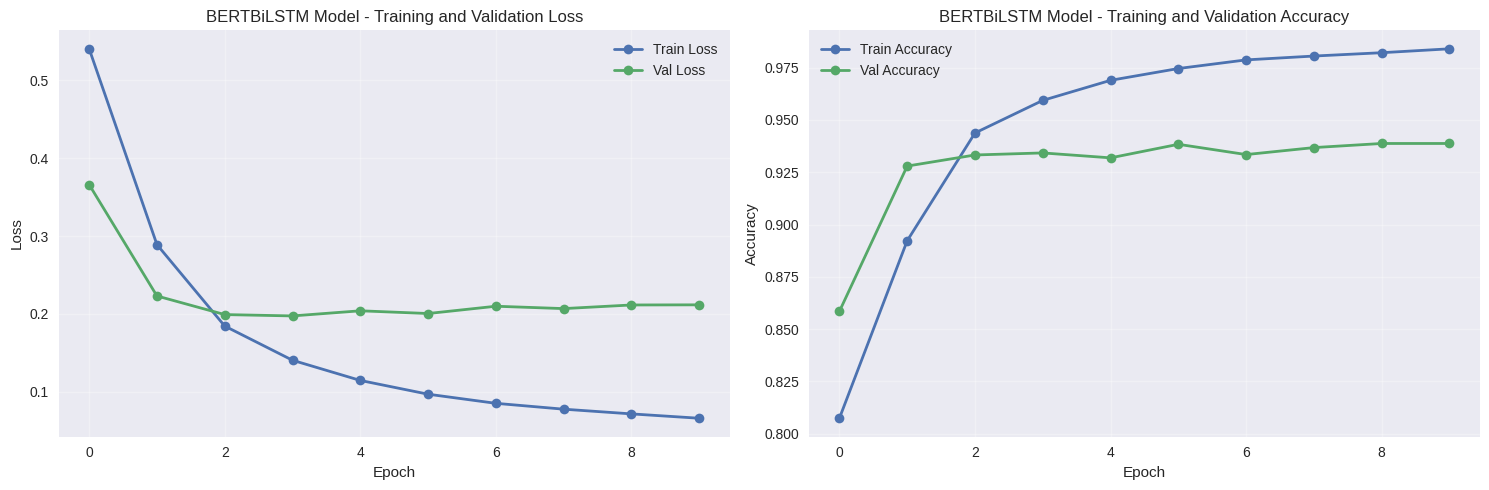


✓ Training plots saved as 'BERTBiLSTM_training_history.png'


In [30]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERTBiLSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERTBiLSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTBiLSTM_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training plots saved as 'BERTBiLSTM_training_history.png'")


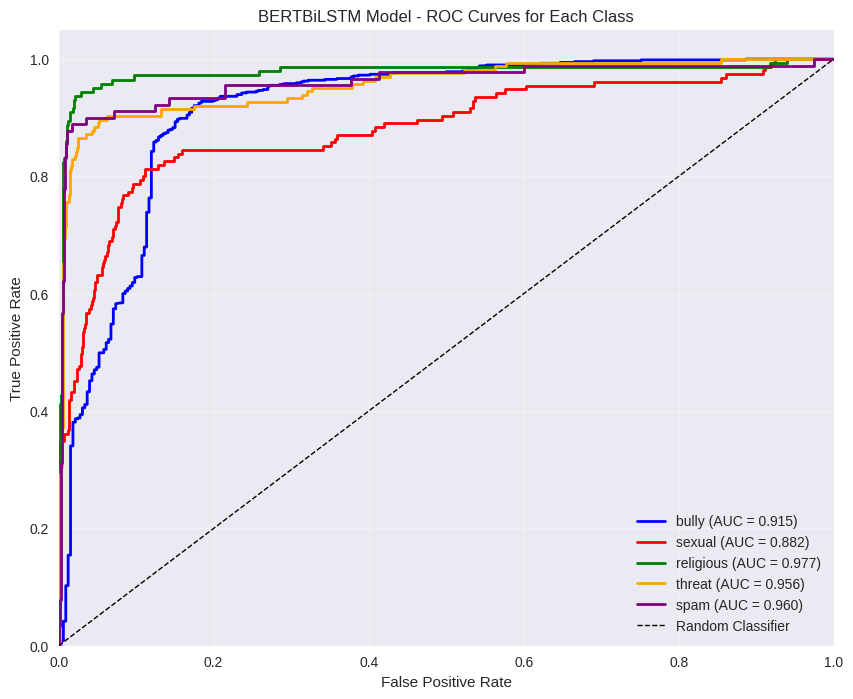

In [31]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERTBiLSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERTBiLSTM_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


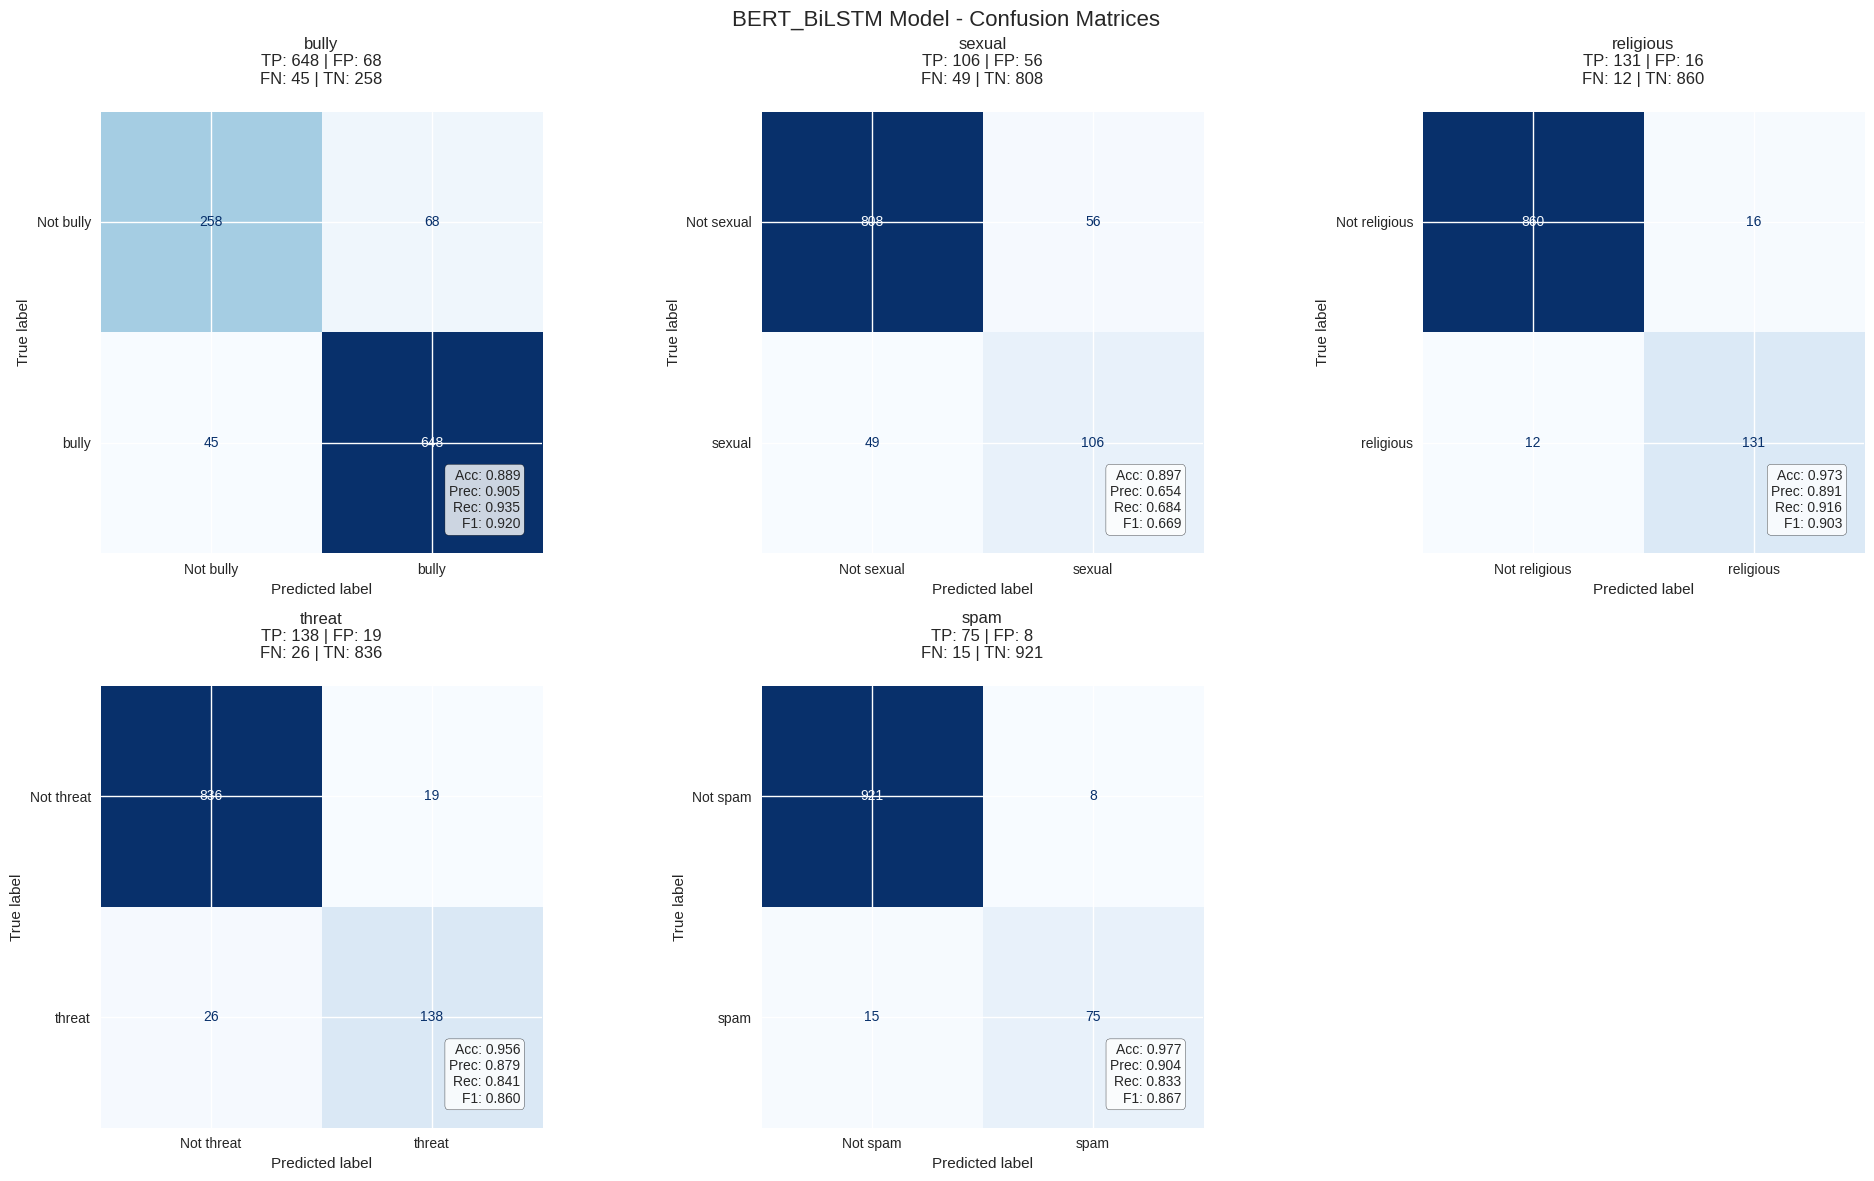

In [32]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix,ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT_BiLSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [33]:
# ========================
# 10. SAMPLE PREDICTIONS
# ========================

def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()
    
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.973), True=1
  sexual: Pred=0 (prob: 0.020), True=0
  religious: Pred=0 (prob: 0.039), True=0
  threat: Pred=1 (prob: 0.955), True=1
  spam: Pred=0 (prob: 0.013), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.026), True=0
  sexual: Pred=0 (prob: 0.033), True=0
  religious: Pred=0 (prob: 0.030), True=0
  threat: Pred=0 (prob: 0.012), True=0
  spam: Pred=1 (prob: 0.948), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.989), True=1
  sexual: Pred=1 (prob: 0.959), True=1
  religious: Pred=0 (prob: 0.014), True=0
  threat: Pred=0 (prob: 0.019), True=0
  spam: Pred=0 (prob: 0.018), True=0


# ============================ END ==========================

# ================== BERT + LSTM ========================

In [31]:
# ========================
# 3. MODEL ARCHITECTURE: BERT + LSTM
# ========================

class BERTLSTM(nn.Module):
    def __init__(self, bert_model_name, num_labels, hidden_dim=256, lstm_layers=2, dropout=0.3):
        super(BERTLSTM, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.lstm = nn.LSTM(
            self.bert.config.hidden_size,
            hidden_dim,
            num_layers=lstm_layers,
            bidirectional=False,  # Single direction LSTM
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_labels)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        
        lstm_output, (hidden, cell) = self.lstm(sequence_output)
        # Use the last hidden state from the last layer
        last_hidden = hidden[-1, :, :]  # (batch, hidden_dim)
        
        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden)
        return logits


In [32]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-5

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BERT+LSTM model
model = BERTLSTM(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTLSTM")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



Model: BERTLSTM
Total parameters: 337,446,149


In [33]:
# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [34]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BERTLSTM")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bert_lstm.pt')
    print(f"✓ Last BERTLSTM model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BERTLSTM")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BERTLSTM:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")



STARTING TRAINING - BERTLSTM

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.5206 | Train Acc: 0.8113
Val Loss: 0.3225 | Val Acc: 0.8907
✓ Last BERTLSTM model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0723 | Train Acc: 0.9849
Val Loss: 0.2075 | Val Acc: 0.9372
✓ Last BERTLSTM model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0669 | Train Acc: 0.9864
Val Loss: 0.2092 | Val Acc: 0.9354
✓ Last BERTLSTM model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BERTLSTM

FINAL TRAINING METRICS - BERTLSTM:
Last Train Loss: 0.0669
Last Train Accuracy: 0.9864
Last Validation Loss: 0.2092
Last Validation Accuracy: 0.9354


In [35]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BERTLSTM MODEL")
print("="*50)

# Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bert_lstm.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BERTLSTM")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")



TESTING WITH LAST BERTLSTM MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BERTLSTM
Test Loss: 0.1944
Test Accuracy: 0.9417
Hamming Loss: 0.0583


In [36]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8835
Recall: 0.8771
F1-Score: 0.8803


In [39]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7397, Cohen's Kappa = 0.7391
    sexual: MCC = 0.6405, Cohen's Kappa = 0.6385
 religious: MCC = 0.9246, Cohen's Kappa = 0.9243
    threat: MCC = 0.8143, Cohen's Kappa = 0.8137
      spam: MCC = 0.8510, Cohen's Kappa = 0.8508

Average Scores:
MCC: 0.7940
Cohen's Kappa: 0.7933


In [40]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BERTLSTM")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BERTLSTM
              precision    recall  f1-score   support

       bully       0.91      0.93      0.92       693
      sexual       0.74      0.65      0.69       155
   religious       0.91      0.96      0.94       143
      threat       0.87      0.82      0.84       164
        spam       0.88      0.84      0.86        90

   micro avg       0.88      0.88      0.88      1245
   macro avg       0.86      0.84      0.85      1245
weighted avg       0.88      0.88      0.88      1245
 samples avg       0.73      0.72      0.72      1245



In [41]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BERTLSTM")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BERTLSTM
bully: 0.9191
sexual: 0.8526
religious: 0.9839
threat: 0.9441
spam: 0.9331

Micro AUC: 0.9575
Macro AUC: 0.9266


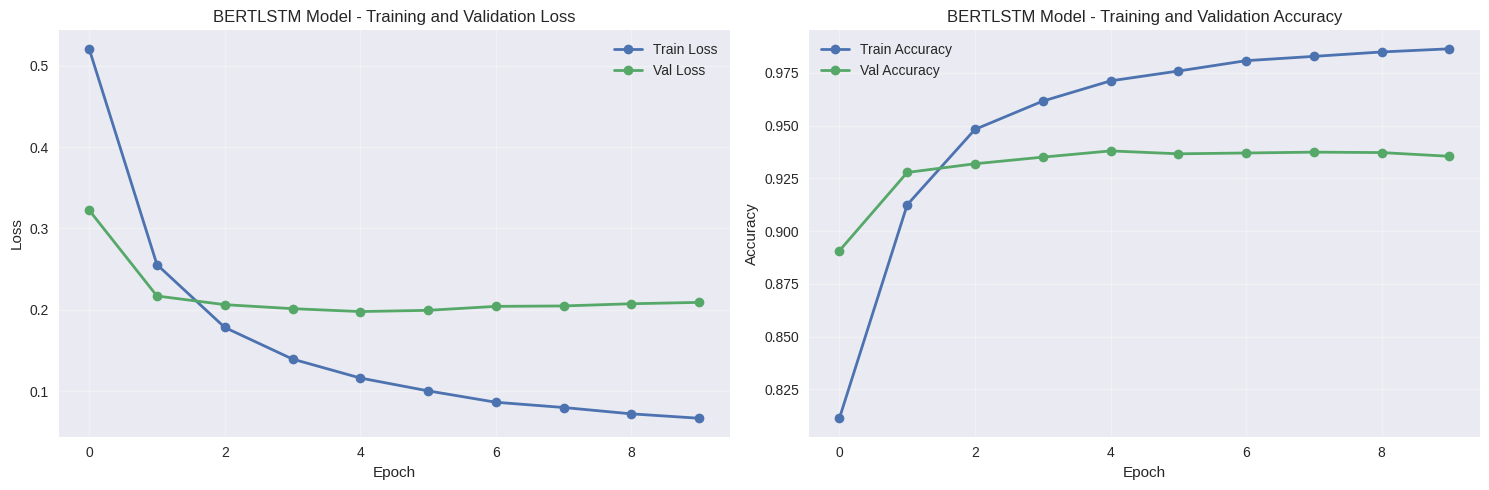

In [42]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERTLSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERTLSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTLSTM_training_history.png', dpi=300, bbox_inches='tight')
plt.show()


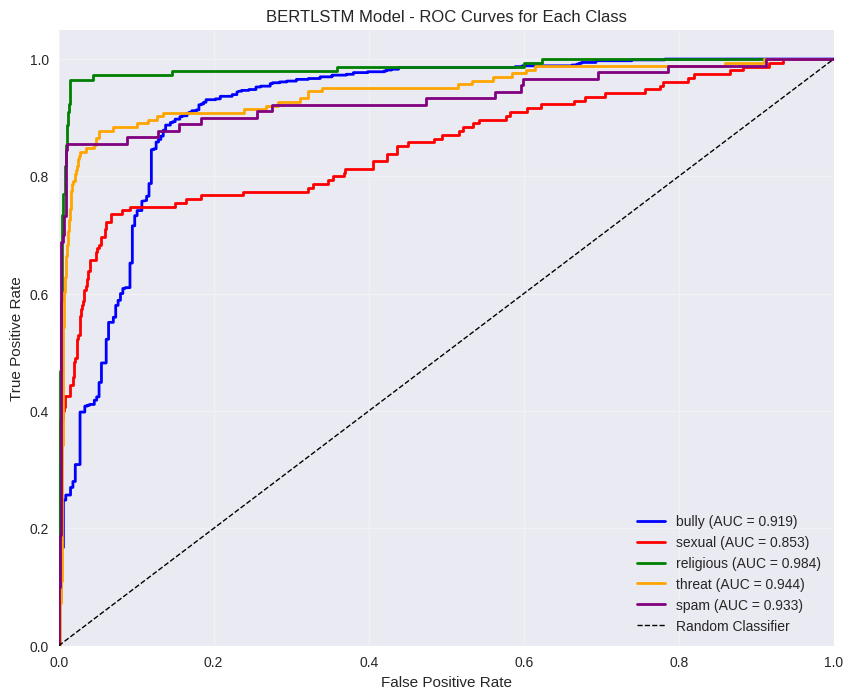

In [43]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERTLSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERTLSTM_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


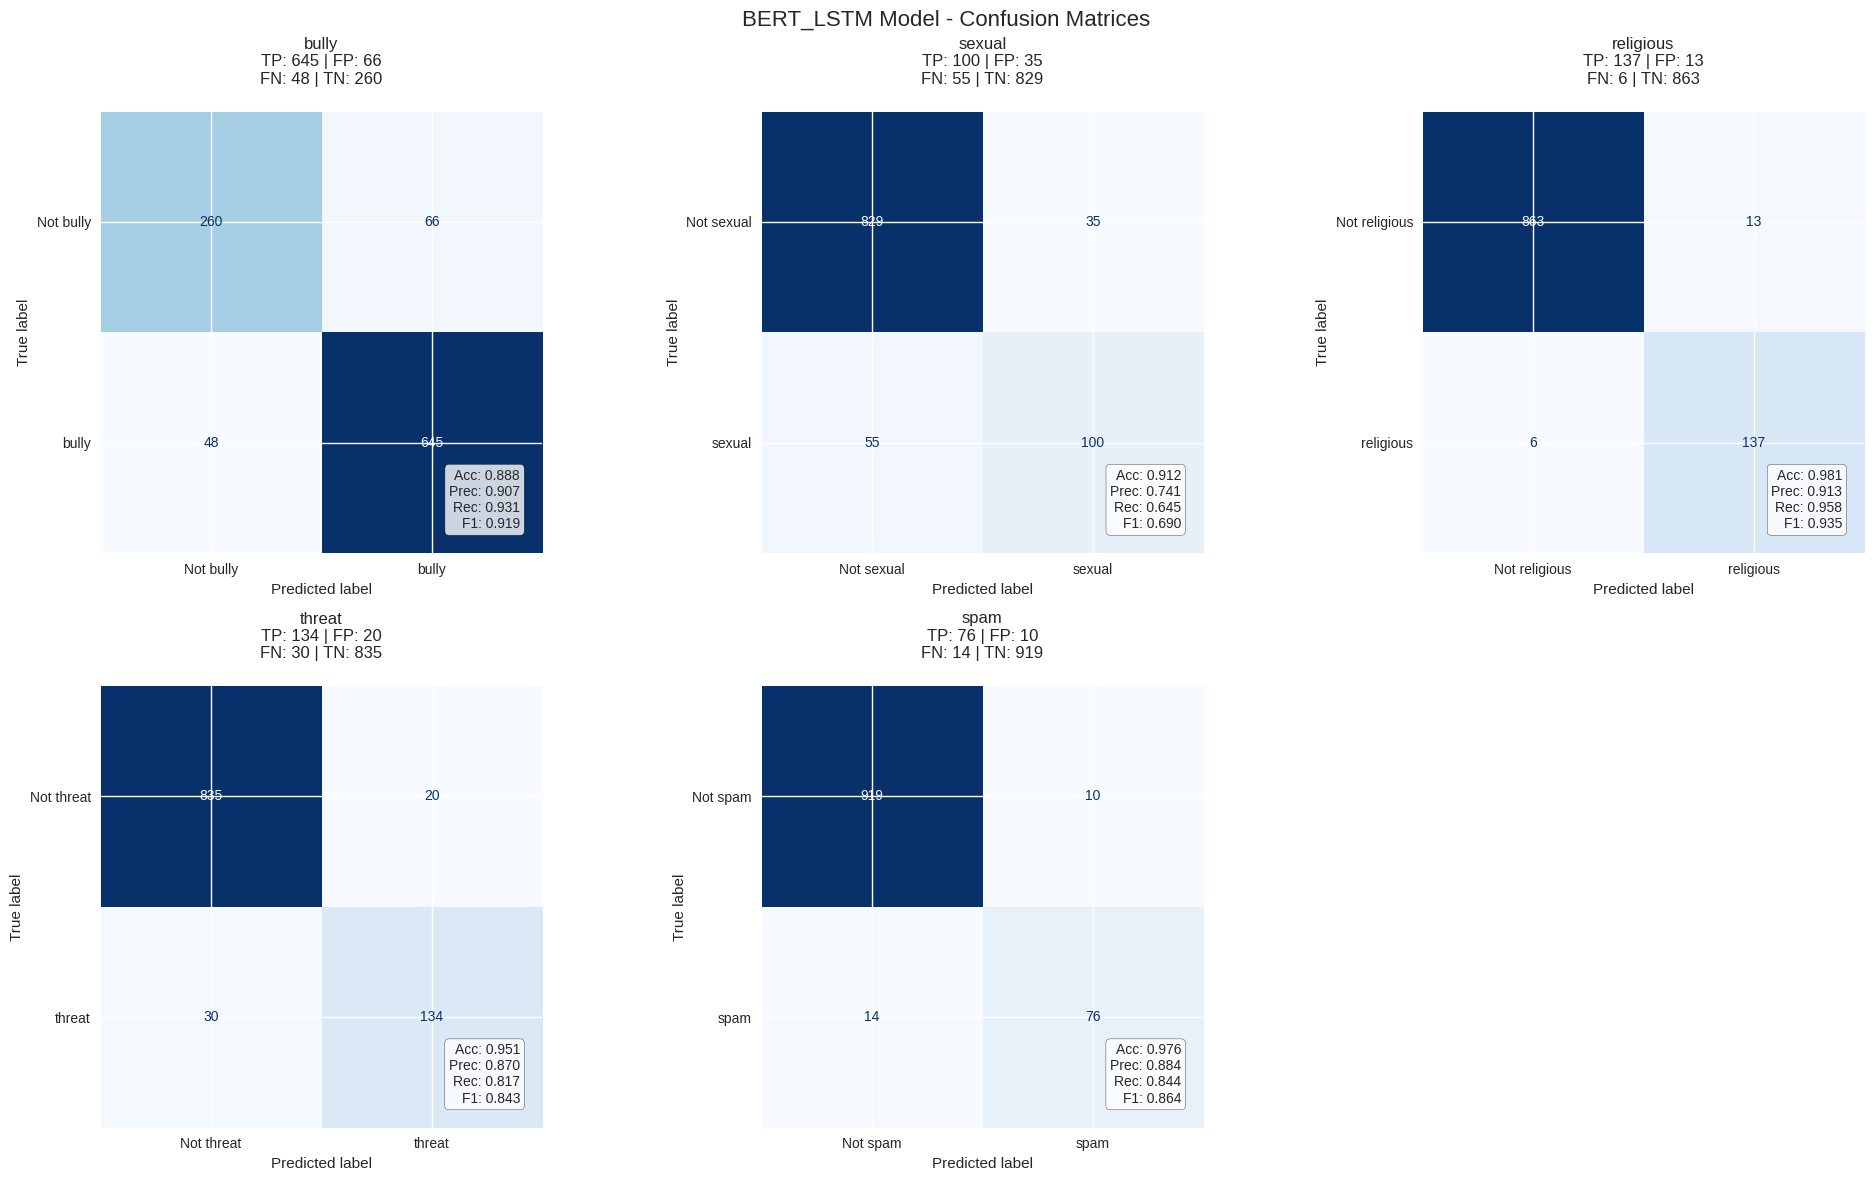

In [44]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT_LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [45]:
# ========================
# 10. SAMPLE PREDICTIONS
# ========================

def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()
    
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BERTLSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BERTLSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.967), True=1
  sexual: Pred=0 (prob: 0.031), True=0
  religious: Pred=0 (prob: 0.027), True=0
  threat: Pred=1 (prob: 0.930), True=1
  spam: Pred=0 (prob: 0.021), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.026), True=0
  sexual: Pred=0 (prob: 0.036), True=0
  religious: Pred=0 (prob: 0.031), True=0
  threat: Pred=0 (prob: 0.017), True=0
  spam: Pred=1 (prob: 0.943), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.984), True=1
  sexual: Pred=1 (prob: 0.948), True=1
  religious: Pred=0 (prob: 0.025), True=0
  threat: Pred=0 (prob: 0.034), True=0
  spam: Pred=0 (prob: 0.017), True=0


# ================= END =============================

# ====================== BERT + Bi-GRU ==================

In [47]:
# ========================
# 3. MODEL ARCHITECTURE: BERT + Bi-GRU
# ========================

class BERTBiGRU(nn.Module):
    def __init__(self, bert_model_name, num_labels, hidden_dim=256, gru_layers=2, dropout=0.3):
        super(BERTBiGRU, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.gru = nn.GRU(
            self.bert.config.hidden_size,
            hidden_dim,
            num_layers=gru_layers,
            bidirectional=True,  # Bidirectional GRU
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        
        gru_output, hidden = self.gru(sequence_output)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [48]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-5

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BERT+Bi-GRU model
model = BERTBiGRU(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTBiGRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model: BERTBiGRU
Total parameters: 338,760,197


In [49]:
# Optimizer and scheduler 
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [50]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BERTBiGRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bert_bigru.pt')
    print(f"✓ Last BERTBiGRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BERTBiGRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BERTBiGRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BERTBiGRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.4574 | Train Acc: 0.8106
Val Loss: 0.2712 | Val Acc: 0.9046
✓ Last BERTBiGRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0610 | Train Acc: 0.9850
Val Loss: 0.2162 | Val Acc: 0.9348
✓ Last BERTBiGRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0572 | Train Acc: 0.9864
Val Loss: 0.2176 | Val Acc: 0.9348
✓ Last BERTBiGRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BERTBiGRU

FINAL TRAINING METRICS - BERTBiGRU:
Last Train Loss: 0.0572
Last Train Accuracy: 0.9864
Last Validation Loss: 0.2176
Last Validation Accuracy: 0.9348


In [51]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BERTBiGRU MODEL")
print("="*50)

# Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bert_bigru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BERTBiGRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST BERTBiGRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BERTBiGRU
Test Loss: 0.1997
Test Accuracy: 0.9368
Hamming Loss: 0.0632


In [52]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8591
Recall: 0.8867
F1-Score: 0.8727


In [53]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BERTBiGRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BERTBiGRU
              precision    recall  f1-score   support

       bully       0.89      0.94      0.91       693
      sexual       0.70      0.71      0.70       155
   religious       0.87      0.94      0.90       143
      threat       0.88      0.84      0.86       164
        spam       0.87      0.83      0.85        90

   micro avg       0.86      0.89      0.87      1245
   macro avg       0.84      0.85      0.84      1245
weighted avg       0.86      0.89      0.87      1245
 samples avg       0.72      0.73      0.72      1245



In [54]:

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)



print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7049, Cohen's Kappa = 0.7021
    sexual: MCC = 0.6490, Cohen's Kappa = 0.6490
 religious: MCC = 0.8866, Cohen's Kappa = 0.8857
    threat: MCC = 0.8299, Cohen's Kappa = 0.8295
      spam: MCC = 0.8386, Cohen's Kappa = 0.8383

Average Scores:
MCC: 0.7818
Cohen's Kappa: 0.7809


In [55]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BERTBiGRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS - BERTBiGRU
bully: 0.9194
sexual: 0.8758
religious: 0.9838
threat: 0.9578
spam: 0.9604

Micro AUC: 0.9625
Macro AUC: 0.9395


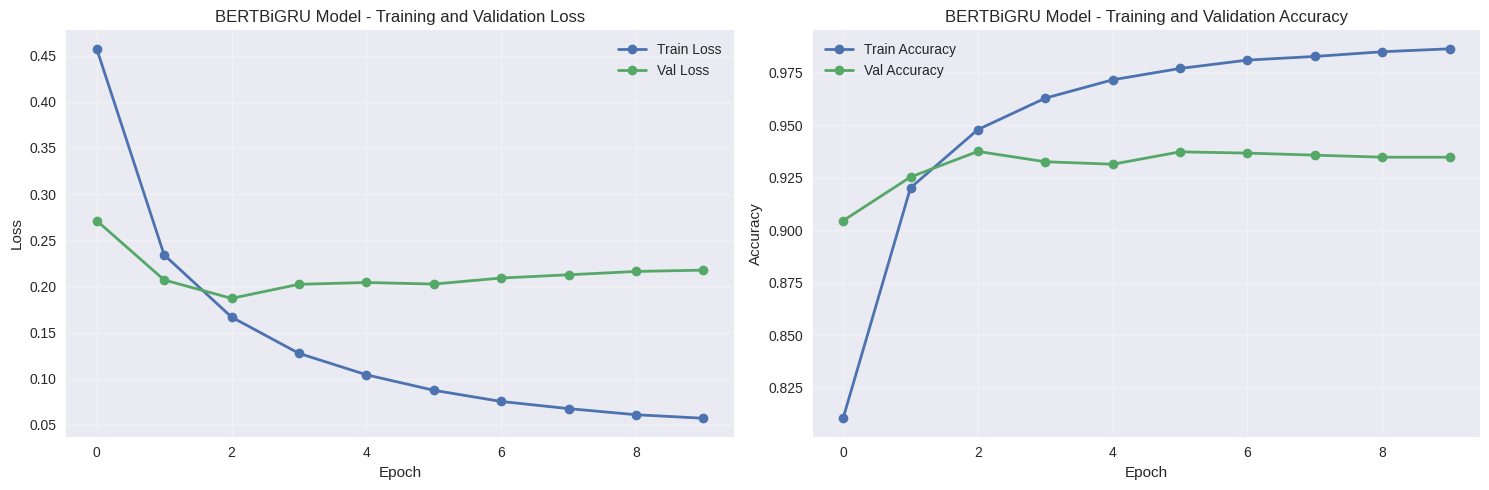

In [56]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERTBiGRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERTBiGRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTBiGRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()


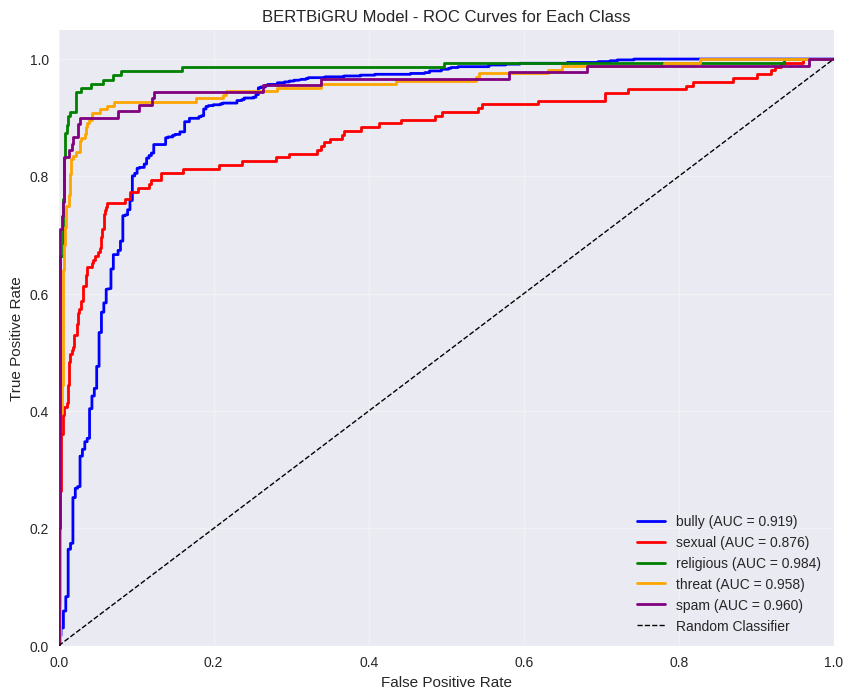

In [57]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERTBiGRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERTBiGRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()



COMPREHENSIVE CONFUSION MATRIX


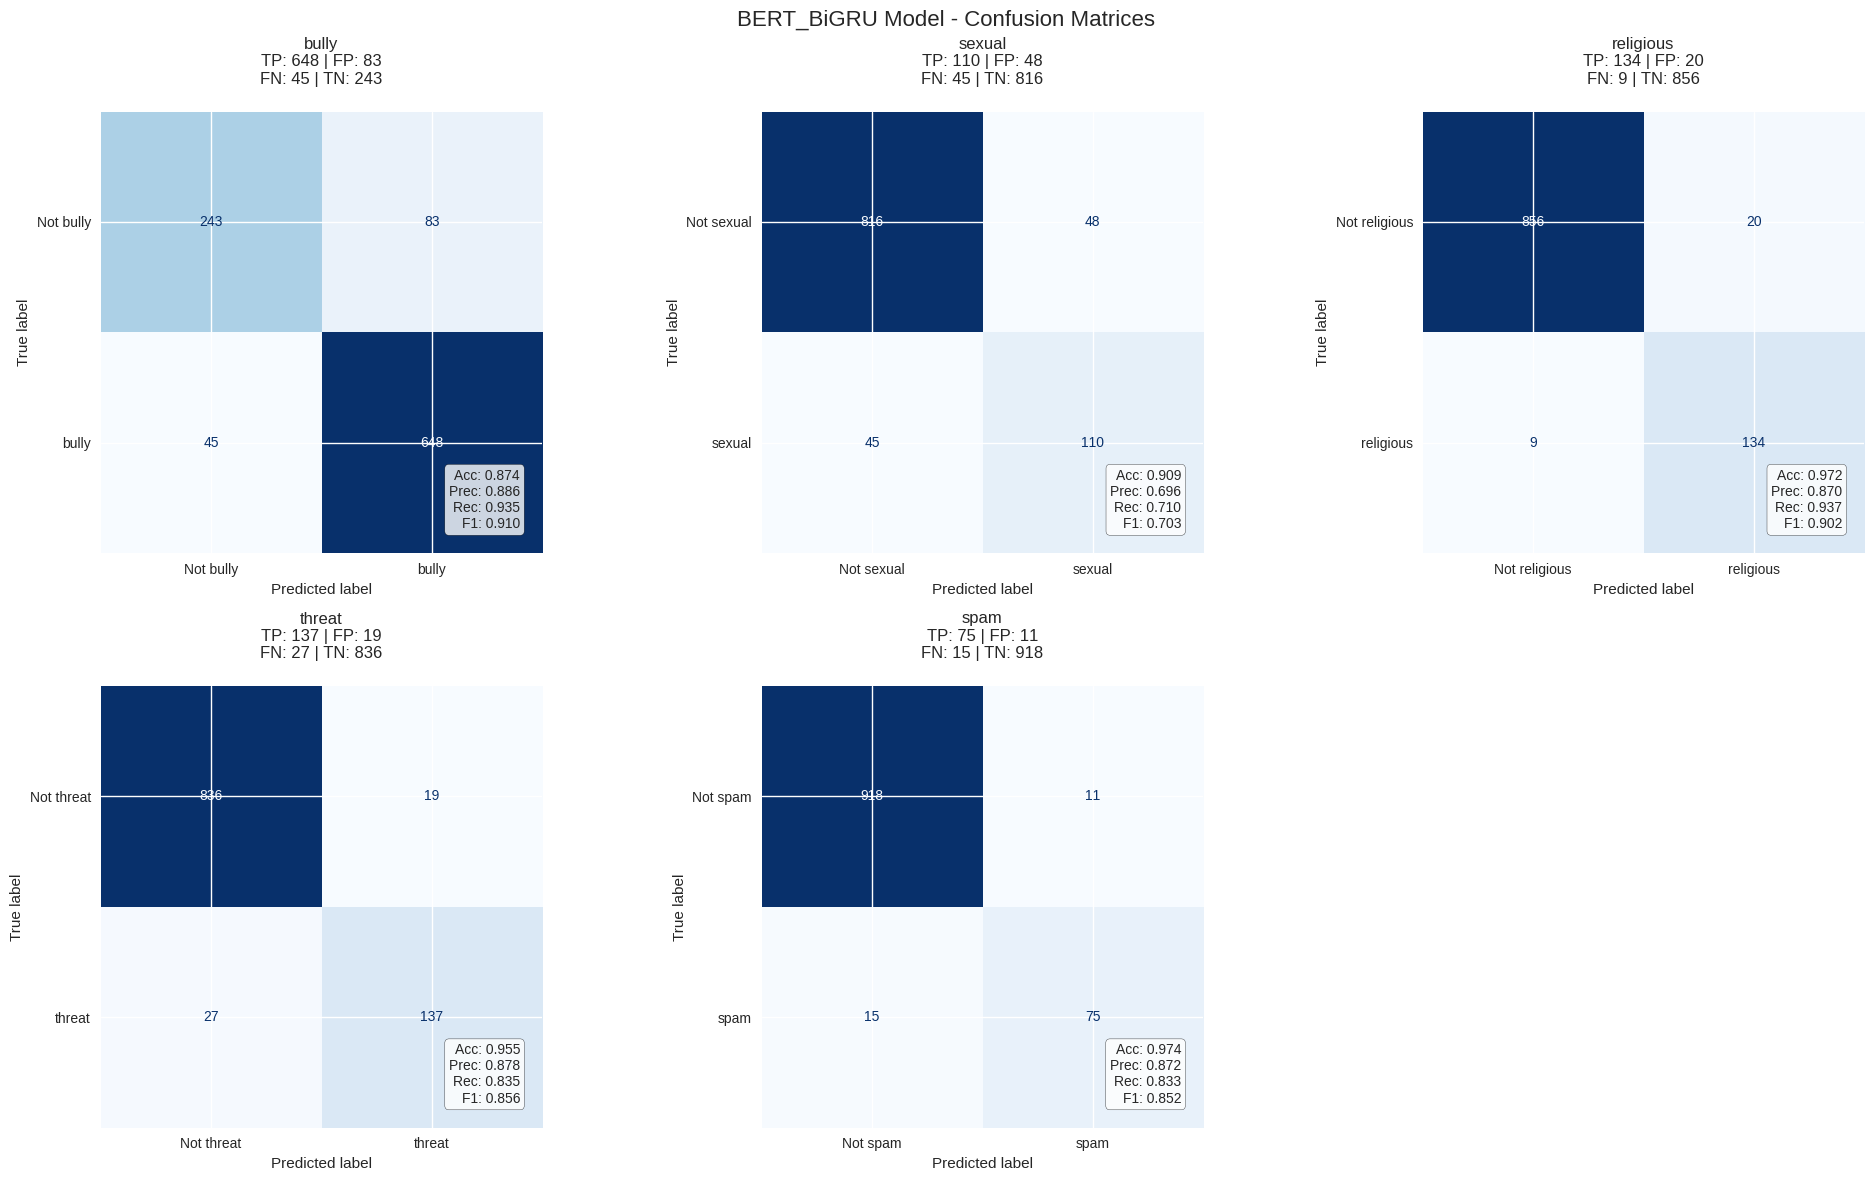

In [58]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT_BiGRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [59]:
def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()
    
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BERTBiGRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BERTBiGRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.980), True=1
  sexual: Pred=0 (prob: 0.019), True=0
  religious: Pred=0 (prob: 0.039), True=0
  threat: Pred=1 (prob: 0.966), True=1
  spam: Pred=0 (prob: 0.016), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.013), True=0
  sexual: Pred=0 (prob: 0.025), True=0
  religious: Pred=0 (prob: 0.032), True=0
  threat: Pred=0 (prob: 0.015), True=0
  spam: Pred=1 (prob: 0.969), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.985), True=1
  sexual: Pred=1 (prob: 0.978), True=1
  religious: Pred=0 (prob: 0.019), True=0
  threat: Pred=0 (prob: 0.017), True=0
  spam: Pred=0 (prob: 0.022), True=0


# ========================= END ========================================

# =================== BERT + GRU =======================

In [26]:
# ========================
# 3. MODEL ARCHITECTURE: BERT + GRU
# ========================

class BERTGRU(nn.Module):
    def __init__(self, bert_model_name, num_labels, hidden_dim=256, gru_layers=2, dropout=0.3):
        super(BERTGRU, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.gru = nn.GRU(
            self.bert.config.hidden_size,
            hidden_dim,
            num_layers=gru_layers,
            bidirectional=False,  # Single direction GRU
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_labels)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        
        gru_output, hidden = self.gru(sequence_output)
        # Use the last hidden state from the last layer
        last_hidden = hidden[-1, :, :]  # (batch, hidden_dim)
        
        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden)
        return logits

In [27]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-5

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BERT+GRU model
model = BERTGRU(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTGRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model: BERTGRU
Total parameters: 336,591,621


In [28]:
# Optimizer and scheduler 
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE )
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [29]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BERTGRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bert_gru.pt')
    print(f"✓ Last BERTGRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BERTGRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BERTGRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BERTGRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.4383 | Train Acc: 0.8027
Val Loss: 0.2587 | Val Acc: 0.9123
✓ Last BERTGRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0687 | Train Acc: 0.9868
Val Loss: 0.2058 | Val Acc: 0.9331
✓ Last BERTGRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0658 | Train Acc: 0.9877
Val Loss: 0.2054 | Val Acc: 0.9362
✓ Last BERTGRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BERTGRU

FINAL TRAINING METRICS - BERTGRU:
Last Train Loss: 0.0658
Last Train Accuracy: 0.9877
Last Validation Loss: 0.2054
Last Validation Accuracy: 0.9362


In [30]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BERTGRU MODEL")
print("="*50)

# Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bert_gru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BERTGRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST BERTGRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BERTGRU
Test Loss: 0.1886
Test Accuracy: 0.9397
Hamming Loss: 0.0603


In [31]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)
print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8676
Recall: 0.8892
F1-Score: 0.8782


In [32]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BERTGRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BERTGRU
              precision    recall  f1-score   support

       bully       0.90      0.94      0.92       693
      sexual       0.68      0.66      0.67       155
   religious       0.88      0.95      0.92       143
      threat       0.88      0.87      0.87       164
        spam       0.86      0.83      0.85        90

   micro avg       0.87      0.89      0.88      1245
   macro avg       0.84      0.85      0.85      1245
weighted avg       0.87      0.89      0.88      1245
 samples avg       0.73      0.73      0.72      1245



In [34]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7383, Cohen's Kappa = 0.7365
    sexual: MCC = 0.6156, Cohen's Kappa = 0.6155
 religious: MCC = 0.9023, Cohen's Kappa = 0.9015
    threat: MCC = 0.8500, Cohen's Kappa = 0.8499
      spam: MCC = 0.8331, Cohen's Kappa = 0.8330

Average Scores:
MCC: 0.7878
Cohen's Kappa: 0.7873


In [35]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BERTGRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BERTGRU
bully: 0.9205
sexual: 0.8709
religious: 0.9831
threat: 0.9698
spam: 0.9596

Micro AUC: 0.9644
Macro AUC: 0.9408


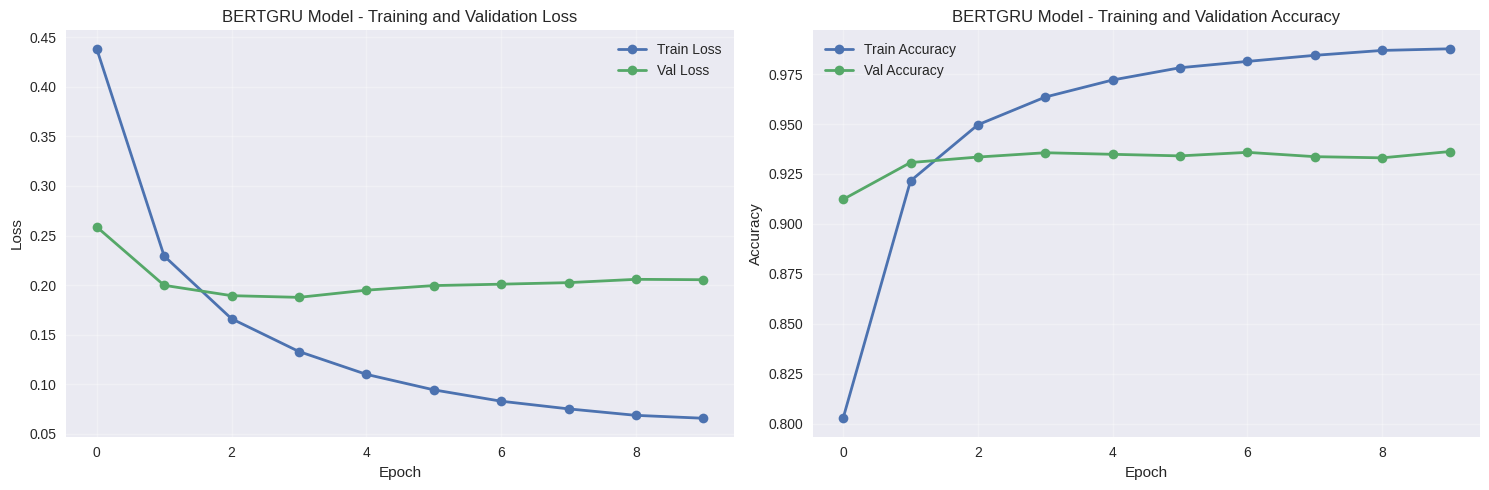

In [36]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERTGRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERTGRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTGRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

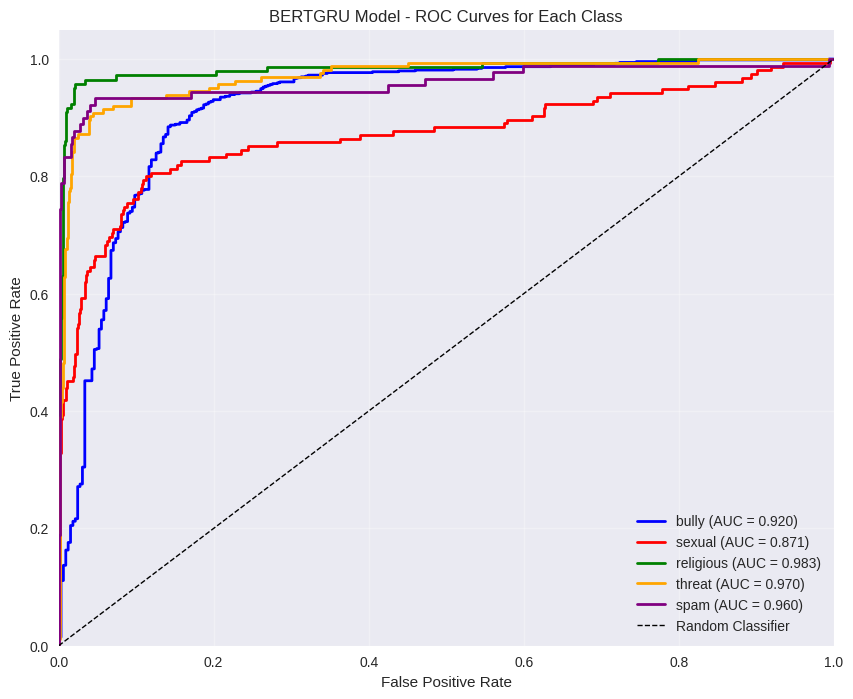

In [37]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERTGRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERTGRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


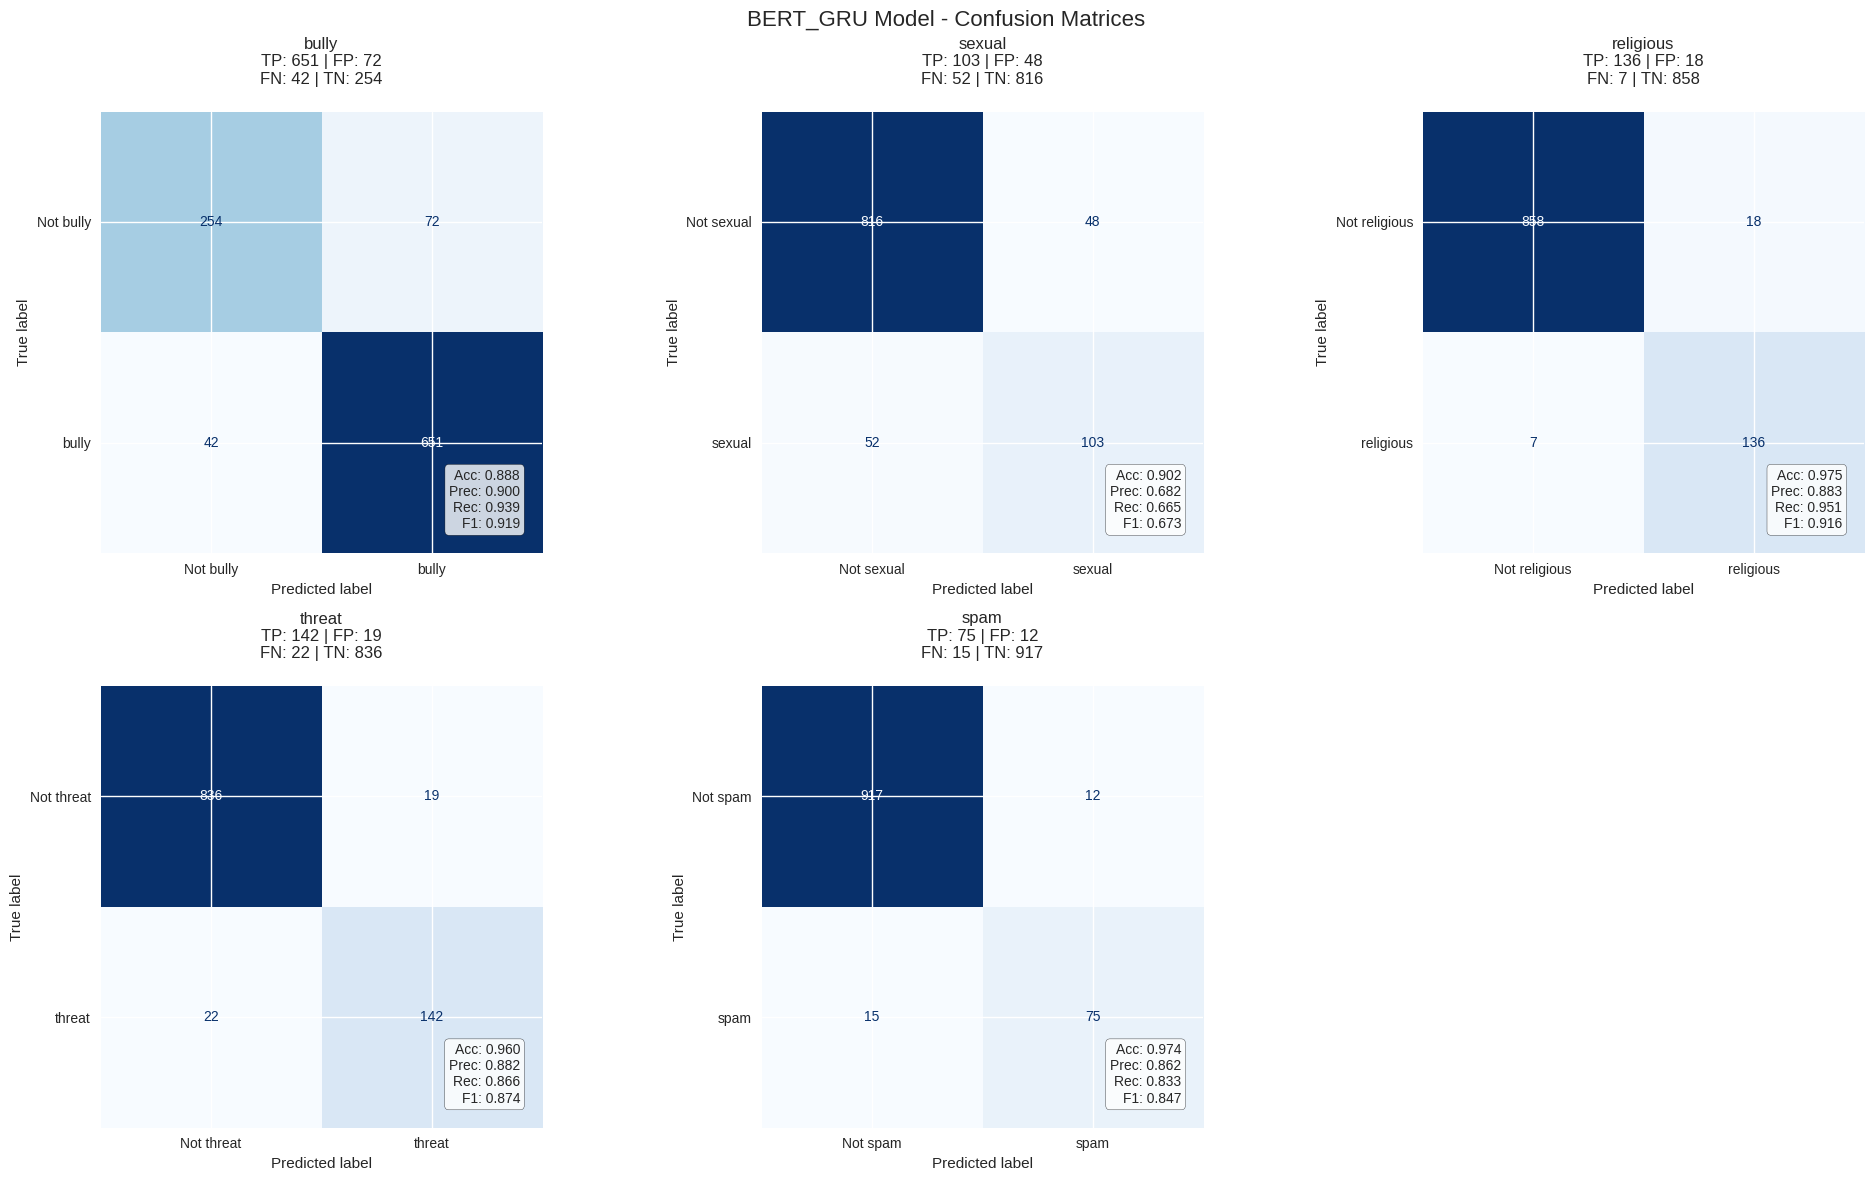

In [38]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT_GRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [39]:
# ========================
# 10. SAMPLE PREDICTIONS
# ========================

def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()
    
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BERTGRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BERTGRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.959), True=1
  sexual: Pred=0 (prob: 0.027), True=0
  religious: Pred=0 (prob: 0.033), True=0
  threat: Pred=1 (prob: 0.945), True=1
  spam: Pred=0 (prob: 0.043), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.024), True=0
  sexual: Pred=0 (prob: 0.034), True=0
  religious: Pred=0 (prob: 0.035), True=0
  threat: Pred=0 (prob: 0.033), True=0
  spam: Pred=1 (prob: 0.966), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.973), True=1
  sexual: Pred=1 (prob: 0.963), True=1
  religious: Pred=0 (prob: 0.031), True=0
  threat: Pred=0 (prob: 0.031), True=0
  spam: Pred=0 (prob: 0.027), True=0


# ==================== END ============================

# =================  BERT ONLY ==============

In [73]:
# BERT Only

class BERTOnly(nn.Module):
    def __init__(self, bert_model_name, num_labels, dropout=0.3):
        super(BERTOnly, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use the [CLS] token representation from the last hidden state
        last_hidden_state = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)
        cls_output = last_hidden_state[:, 0, :]  # Take [CLS] token (batch_size, hidden_size)
        
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [74]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

# Configuration 
BERT_MODEL = 'csebuetnlp/banglabert_large'
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-5

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BERT-only model
model = BERTOnly(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTOnly")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model: BERTOnly
Total parameters: 335,610,885


In [75]:
# Optimizer and scheduler (SAME AS BEFORE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [76]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BERTOnly")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bert_only.pt')
    print(f"✓ Last BERTOnly model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BERTOnly")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BERTOnly:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BERTOnly

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.4582 | Train Acc: 0.7840
Val Loss: 0.2608 | Val Acc: 0.9021
✓ Last BERTOnly model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0557 | Train Acc: 0.9860
Val Loss: 0.2316 | Val Acc: 0.9321
✓ Last BERTOnly model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/255 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0510 | Train Acc: 0.9882
Val Loss: 0.2322 | Val Acc: 0.9337
✓ Last BERTOnly model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BERTOnly

FINAL TRAINING METRICS - BERTOnly:
Last Train Loss: 0.0510
Last Train Accuracy: 0.9882
Last Validation Loss: 0.2322
Last Validation Accuracy: 0.9337


In [77]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BERTOnly MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bert_only.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BERTOnly")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST BERTOnly MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BERTOnly
Test Loss: 0.2018
Test Accuracy: 0.9392
Hamming Loss: 0.0608


In [78]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8702
Recall: 0.8827
F1-Score: 0.8764


In [79]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BERTOnly")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BERTOnly
              precision    recall  f1-score   support

       bully       0.90      0.93      0.92       693
      sexual       0.68      0.65      0.66       155
   religious       0.91      0.92      0.91       143
      threat       0.85      0.87      0.86       164
        spam       0.90      0.88      0.89        90

   micro avg       0.87      0.88      0.88      1245
   macro avg       0.85      0.85      0.85      1245
weighted avg       0.87      0.88      0.88      1245
 samples avg       0.73      0.73      0.72      1245



In [80]:


# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7297, Cohen's Kappa = 0.7286
    sexual: MCC = 0.6067, Cohen's Kappa = 0.6064
 religious: MCC = 0.8986, Cohen's Kappa = 0.8986
    threat: MCC = 0.8346, Cohen's Kappa = 0.8345
      spam: MCC = 0.8770, Cohen's Kappa = 0.8769

Average Scores:
MCC: 0.7893
Cohen's Kappa: 0.7890


In [81]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BERTOnly")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BERTOnly
bully: 0.9127
sexual: 0.8796
religious: 0.9863
threat: 0.9603
spam: 0.9510

Micro AUC: 0.9619
Macro AUC: 0.9380


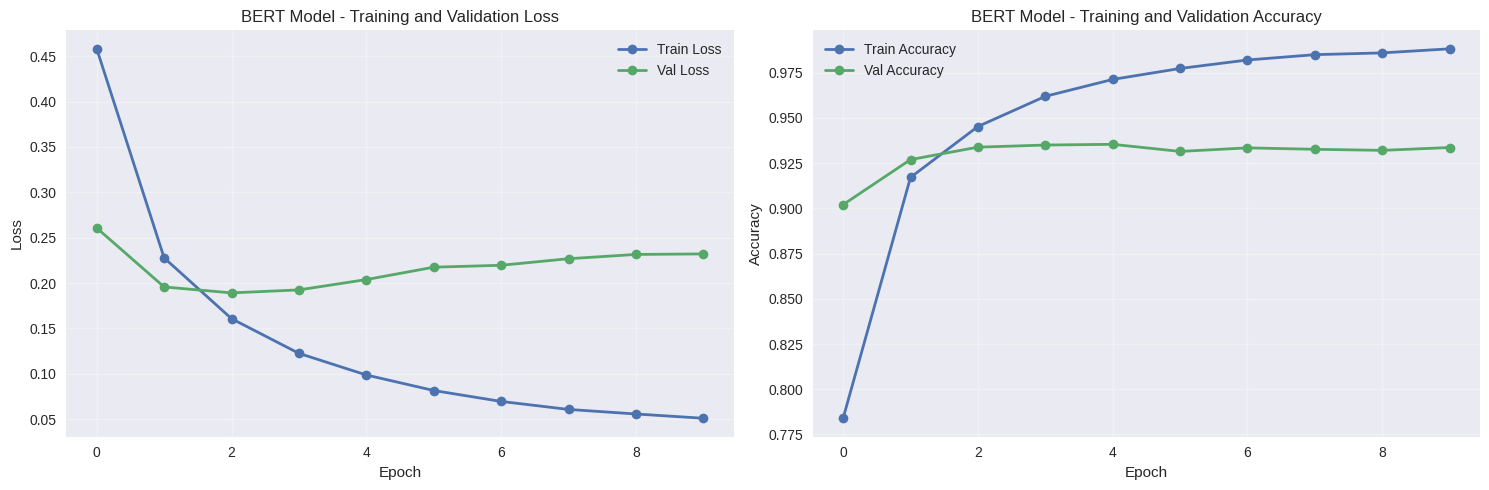

In [82]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERT Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERT Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTOnly_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

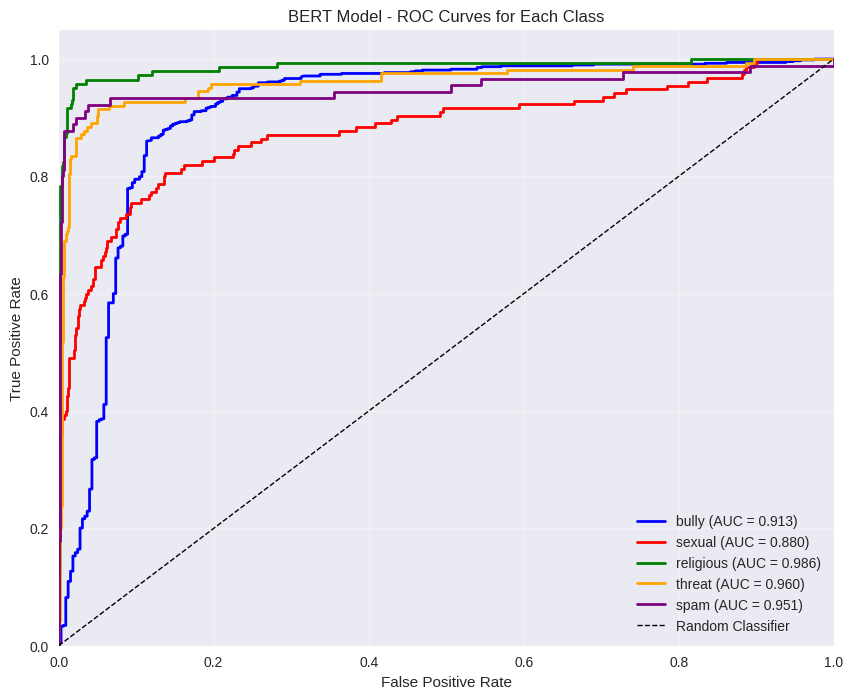

In [83]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERT Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERT_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


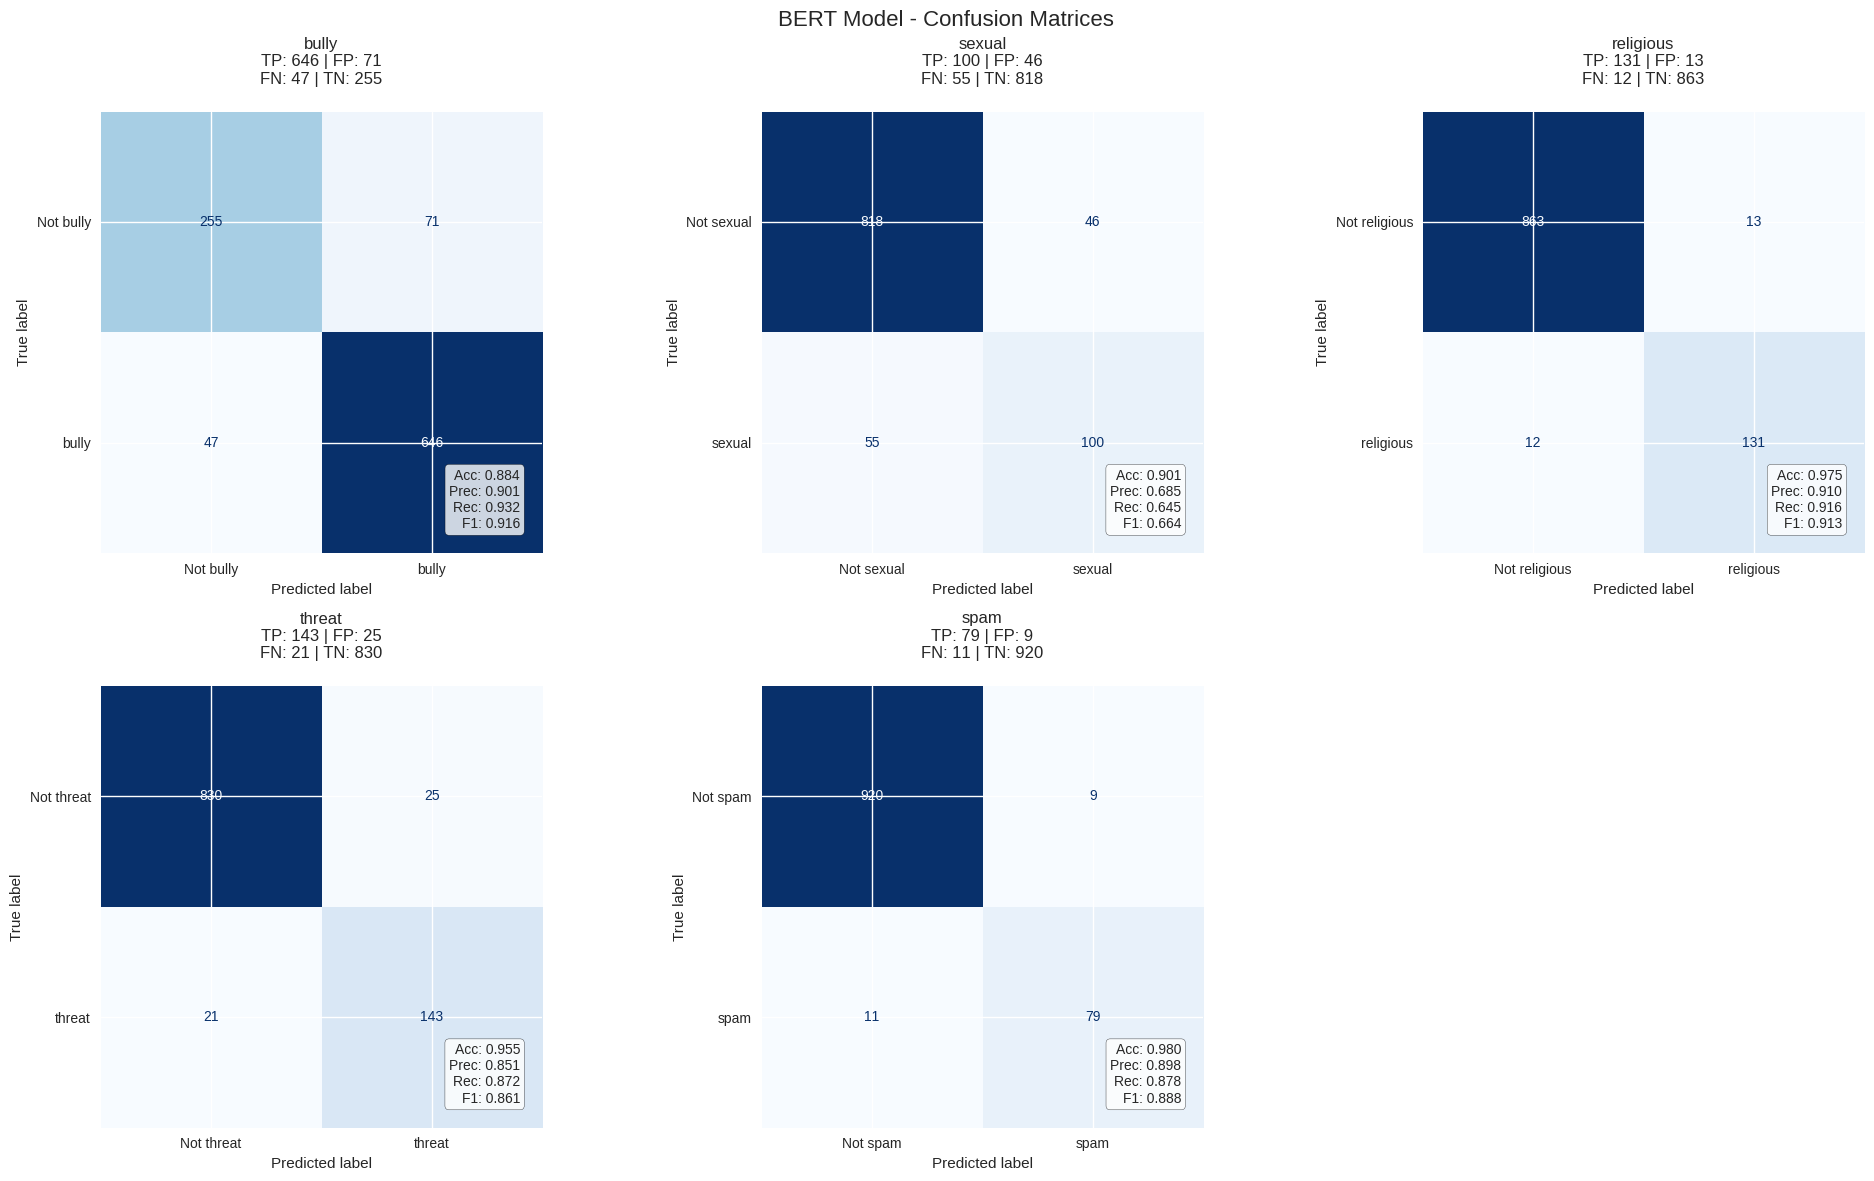

In [84]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [85]:
# ========================
# 10. SAMPLE PREDICTIONS
# ========================

def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()
    
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BERT")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BERT

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.973), True=1
  sexual: Pred=0 (prob: 0.010), True=0
  religious: Pred=0 (prob: 0.015), True=0
  threat: Pred=1 (prob: 0.984), True=1
  spam: Pred=0 (prob: 0.017), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.014), True=0
  sexual: Pred=0 (prob: 0.019), True=0
  religious: Pred=0 (prob: 0.024), True=0
  threat: Pred=0 (prob: 0.016), True=0
  spam: Pred=1 (prob: 0.983), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.988), True=1
  sexual: Pred=1 (prob: 0.992), True=1
  religious: Pred=0 (prob: 0.014), True=0
  threat: Pred=0 (prob: 0.013), True=0
  spam: Pred=0 (prob: 0.015), True=0


# ================= END ===============================